# Händlerübergreifende Wettbewerbsanalyse

Dieses Notebook untersucht die Preisunterschiede und mögliche zeitlich nachfolgende Preisreaktionen zwischen **Tennistown**, **Tennis-Heine** und **Tennis-Point** im Erhebungszeitraum vom 14.06.2026 bis zum 17.07.2026.

Im Mittelpunkt stehen:

- der Umfang der eindeutig über `gtin_normalized` zuordenbaren gemeinsamen Produktvarianten
- Preisunterschiede identischer Produktvarianten bei vergleichbaren Abrufen
- die Frage, welcher Händler bei den betrachteten Angeboten am häufigsten den niedrigsten Preis aufweist
- ausgewählte Fälle zeitlich aufeinanderfolgender Preisänderungen

Für die händlerübergreifende Zuordnung werden ausschließlich Produktvarianten verwendet, deren normalisierte GTIN bei allen drei Händlern beobachtet wurde. Fehlende Produktbeobachtungen werden nicht ergänzt und vorhandene Preise nicht künstlich fortgeschrieben. Die Analyse beschränkt sich auf den Preisvergleich eindeutig identifizierbarer Produktvarianten.

> **Hinweis zur Interpretation:** Als preisgünstigster Händler wird zunächst lediglich der Händler mit dem niedrigsten beobachteten Preis für dieselbe Produktvariante und denselben geplanten Abruf bezeichnet. Daraus lässt sich noch keine kausale Preisführerschaft oder Wettbewerbsreaktion ableiten.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- PFAD-KONFIGURATION ---

# Verzeichnis mit dem aufbereiteten Datenbestand
data_processed_dir = '../data/processed'

# Dateiname der aufbereiteten Datentabelle
processed_file_name = 'tennis_data_prepared.csv'

# Vollständigen Dateipfad erzeugen
processed_file_path = os.path.join(data_processed_dir, processed_file_name)

## Aufbereiteten Datenbestand einlesen

Die in `02_data_preparation` erzeugte Datei `tennis_data_prepared.csv` wird als Grundlage der Wettbewerbsanalyse eingelesen.

Die Identifikatoren `product_url_key`, `ean` und `gtin_normalized` werden als Zeichenfolgen geladen. `timestamp` und `run_date` werden als Datumswerte eingelesen, damit die Beobachtungen später zeitlich zugeordnet werden können.

In [3]:
if not os.path.exists(processed_file_path):
    raise FileNotFoundError(f'Die Datei "{processed_file_path}" wurde nicht gefunden.')

df_tennis_data = pd.read_csv(
    processed_file_path,
    encoding='utf-8',
    dtype={
        'product_url_key': 'string',
        'ean': 'string',
        'gtin_normalized': 'string'
    },
    parse_dates=[
        'timestamp',
        'run_date'
    ]
)

print('--- AUFBEREITETER DATENBESTAND EINGELESEN ---')
print(f'Beobachtungen: {len(df_tennis_data)}')
print(f'Spalten: {len(df_tennis_data.columns)}')
print(f'Erhebungszeitraum: {df_tennis_data["timestamp"].min():%d.%m.%Y} bis {df_tennis_data["timestamp"].max():%d.%m.%Y}')

--- AUFBEREITETER DATENBESTAND EINGELESEN ---
Beobachtungen: 87609
Spalten: 19
Erhebungszeitraum: 14.06.2026 bis 17.07.2026


In [4]:
# Beispielhafte Ausgabe der ersten Produktbeobachtungen
display(df_tennis_data.head())

,retailer,timestamp,run_date,run,source_file,category,gender,brand,name,reference_variant,product_url_key,ean,gtin_normalized,current_price,regular_price,msrp_price,currency,availability,url
0,Tennistown,2026-06-14 10:13:49,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Boom MP Neon 100in/295g/Tu...,L2,95421,0198772103576,00198772103576,161.96,179.95,260.00,€,in_stock,https://www.tennistown.de/product_info.php?cPa...
1,Tennistown,2026-06-14 10:13:49,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Boom MP Neon 100in/295g/Tu...,L3,95421,0198772103583,00198772103583,161.96,179.95,260.00,€,in_stock,https://www.tennistown.de/product_info.php?cPa...
2,Tennistown,2026-06-14 10:13:54,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Gravity Tour 100in/305g/Tu...,L2,69457,<NA>,<NA>,151.20,168.00,280.00,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...
3,Tennistown,2026-06-14 10:13:54,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Head,Head Tennisschläger Gravity Tour 100in/305g/Tu...,L3,69457,<NA>,<NA>,151.20,168.00,280.00,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...
4,Tennistown,2026-06-14 10:13:57,2026-06-14,run1,tennistown_2026-06-14_run1.csv,rackets,unisex,Yonex,Yonex Tennisschläger EZone (8th Gen.) 98in/305...,L2,87664,<NA>,<NA>,244.90,NaN,279.95,€,out_of_stock,https://www.tennistown.de/product_info.php?cPa...


## Gemeinsame GTINs bestimmen

Für den händlerübergreifenden Preisvergleich werden zunächst die normalisierten GTINs jedes Händlers gesammelt. Anschließend wird die Schnittmenge der GTINs bestimmt, die während des Erhebungszeitraums bei allen drei Händlern mindestens einmal beobachtet wurden.

Eine GTIN wird dabei je Händler nur einmal gezählt, unabhängig davon, wie häufig die zugehörige Produktvariante erfasst wurde. Die Schnittmenge definiert den grundsätzlichen Produktbestand für die folgende Wettbewerbsanalyse.

In [5]:
# --- GEMEINSAME GTINS ALLER DREI HÄNDLER BESTIMMEN ---

# Einheitliche Reihenfolge der Händler festlegen
retailer_order = ['Tennistown', 'Tennis-Heine', 'Tennis-Point']

# Eindeutige normalisierte GTINs jedes Händlers sammeln
gtin_sets = {}

for retailer in retailer_order:
    gtin_sets[retailer] = set(df_tennis_data.loc[df_tennis_data['retailer'].eq(retailer), 'gtin_normalized'].dropna().unique())

# Schnittmenge der bei allen drei Händlern vorhandenen GTINs bilden
common_gtins = set.intersection(*gtin_sets.values())

# Sämtliche Beobachtungen der gemeinsamen Produktvarianten übernehmen
df_common_product_data = (
    df_tennis_data
    .loc[df_tennis_data['gtin_normalized'].isin(common_gtins)]
    .copy()
    .reset_index(drop=True)
)

In [6]:
# --- UMFANG DER GEMEINSAMEN PRODUKTBASIS ZUSAMMENFASSEN ---

# Beobachtungen und gemeinsame GTINs je Händler zählen
df_common_product_overview = (
    df_common_product_data
    .groupby('retailer', sort=False)
    .agg(
        Observations=('gtin_normalized', 'size'),
        Common_GTINs=('gtin_normalized', 'nunique')
    )
    .reset_index()
    .rename(columns={
        'retailer': 'Retailer',
        'Common_GTINs': 'Common GTINs'
    })
)

# Händler in der festgelegten Reihenfolge anordnen
df_common_product_overview = (
    df_common_product_overview
    .set_index('Retailer')
    .reindex(retailer_order)
    .reset_index()
)

print('--- GEMEINSAME GTIN-BASIERTE PRODUKTBASIS ---')
print('Zeigt die Anzahl vorhandener Beobachtungen und gemeinsamer Produktvarianten je Händler an.\n')

display(df_common_product_overview)

print(f'Gemeinsame GTINs aller drei Händler: {len(common_gtins)}')

--- GEMEINSAME GTIN-BASIERTE PRODUKTBASIS ---
Zeigt die Anzahl vorhandener Beobachtungen und gemeinsamer Produktvarianten je Händler an.



,Retailer,Observations,Common GTINs
0,Tennistown,8851,157
1,Tennis-Heine,9006,157
2,Tennis-Point,5309,157


Gemeinsame GTINs aller drei Händler: 157


Insgesamt werden 157 normalisierte GTINs identifiziert, die während des Erhebungszeitraums bei allen drei Händlern mindestens einmal vorkommen. Die unterschiedliche Anzahl zugehöriger Beobachtungen ergibt sich daraus, dass die Produktvarianten je Händler unterschiedlich häufig erfasst wurden. Insbesondere bei Tennis-Point wird der Beobachtungsumfang durch vollständig ausgefallene und teilweise unvollständige Abrufe begrenzt.

Die 157 GTINs bilden zunächst nur die grundsätzliche gemeinsame Produktbasis. Daraus folgt noch nicht, dass die zugehörigen Produktvarianten bei allen drei Händlern zum selben Abruf beobachtet wurden oder gleichzeitig verfügbar waren. Diese Voraussetzungen werden in den folgenden Schritten geprüft.

## Eindeutigkeit der gemeinsamen GTIN-Zuordnungen prüfen

Eine normalisierte GTIN dient im weiteren Verlauf als händlerübergreifender Identifikator einer Produktvariante. Vor dem Preisvergleich wird deshalb ergänzend geprüft, ob jede gemeinsame `gtin_normalized` innerhalb jedes Händlers eindeutig einer Produktvariante zugeordnet ist.

Eine Produktvariante wird hierfür innerhalb eines Händlers durch die Kombination aus `product_url_key` und `reference_variant` bestimmt. Die Prüfung erfolgt über den gesamten Erhebungszeitraum. Unterschiedliche Produktnamen bei ansonsten identischer Produktzuordnung bleiben unberücksichtigt, da sich die Bezeichnung eines Produkts während des Erhebungszeitraums verändern kann.

Wird dieselbe GTIN bei einem Händler mehreren Produktvarianten zugeordnet, ist nicht eindeutig bestimmbar, welche Variante den Angeboten der anderen Händler entspricht. Eine solche GTIN wird deshalb ausschließlich aus der nachfolgenden Wettbewerbsanalyse ausgeschlossen. Die zugehörigen Beobachtungen bleiben im aufbereiteten Gesamtdatensatz unverändert erhalten.

In [7]:
# --- EINDEUTIGKEIT DER GEMEINSAMEN GTIN-ZUORDNUNGEN PRÜFEN ---

# Spalten zur Identifikation einer Produktvariante auswählen; Kategorie, Marke und Name dienen zusätzlich der späteren Kontrollausgabe
df_common_gtin_assignments = (
    df_common_product_data[[
        'retailer',
        'gtin_normalized',
        'product_url_key',
        'reference_variant',
        'category',
        'brand',
        'name'
    ]]
    # Wiederholte Beobachtungen derselben Produktzuordnung entfernen;
    # identisch sind Zeilen mit gleichem Händler, gleicher GTIN, gleichem URL-Produktschlüssel und gleicher Referenzvariante
    .drop_duplicates(subset=[
        'retailer',
        'gtin_normalized',
        'product_url_key',
        'reference_variant'
    ])
)

# Anzahl unterschiedlicher Produktvarianten je Händler und GTIN bestimmen; das Ergebnis wird in jede zugehörige Produktzeile zurückgeschrieben
df_common_gtin_assignments['product_variant_count'] = (
    df_common_gtin_assignments
    .groupby(['retailer', 'gtin_normalized'])['product_url_key']
    .transform('size')
)

# Zuordnungen auswählen, bei denen dieselbe GTIN innerhalb eines Händlers mehr als einer Produktvariante zugeordnet ist
df_ambiguous_gtin_details = (
    df_common_gtin_assignments
    .loc[df_common_gtin_assignments['product_variant_count'].gt(1)]
    .sort_values([
        'retailer',
        'gtin_normalized',
        'product_url_key'
    ])
    .reset_index(drop=True)
)

# Sämtliche GTINs mit mindestens einer uneindeutigen Händlerzuordnung sammeln
ambiguous_gtins = set(df_ambiguous_gtin_details['gtin_normalized'])

# Uneindeutige GTINs aus der Menge der gemeinsamen GTINs ausschließen
usable_common_gtins = common_gtins - ambiguous_gtins

# Anzahl geprüfter, ausgeschlossener und weiterhin nutzbarer GTINs zusammenfassen
df_gtin_uniqueness_overview = pd.DataFrame([{
    'Common GTINs before': len(common_gtins),
    'Ambiguous GTINs excluded': len(ambiguous_gtins),
    'Usable common GTINs': len(usable_common_gtins)
}])

print('--- EINDEUTIGKEIT DER GEMEINSAMEN GTIN-ZUORDNUNGEN ---')
print('Zeigt die Anzahl geprüfter, uneindeutiger und weiterhin nutzbarer gemeinsamer GTINs an.\n')

display(df_gtin_uniqueness_overview)

print('--- UNEINDEUTIGE GTIN-ZUORDNUNGEN ---')
print('Zeigt GTINs, die innerhalb eines Händlers mehreren Produktvarianten zugeordnet sind.\n')

display(df_ambiguous_gtin_details)

--- EINDEUTIGKEIT DER GEMEINSAMEN GTIN-ZUORDNUNGEN ---
Zeigt die Anzahl geprüfter, uneindeutiger und weiterhin nutzbarer gemeinsamer GTINs an.



,Common GTINs before,Ambiguous GTINs excluded,Usable common GTINs
0,157,1,156


--- UNEINDEUTIGE GTIN-ZUORDNUNGEN ---
Zeigt GTINs, die innerhalb eines Händlers mehreren Produktvarianten zugeordnet sind.



,retailer,gtin_normalized,product_url_key,reference_variant,category,brand,name,product_variant_count
0,Tennis-Heine,00887768318024,/wilson-revolve-saitenrolle-orange-200m-56,1.25 mm,strings,Wilson,Wilson Revolve Saitenrolle orange 200m,2
1,Tennis-Heine,00887768318024,/wilson-revolve-saitenrolle-weiss-200m-47,1.25 mm,strings,Wilson,Wilson Revolve Saitenrolle weiß 200m,2


Von den 157 gemeinsamen normalisierten GTINs ist eine GTIN bei Tennis-Heine zwei unterschiedlichen Produktvarianten zugeordnet. Betroffen sind zwei Wilson-Revolve-Saitenrollen derselben Stärke, aber in unterschiedlichen Farben. Anhand der GTIN ist daher nicht eindeutig bestimmbar, welche dieser beiden Produktvarianten den Angeboten der anderen Händler entspricht.

Die betroffene GTIN wird deshalb aus der nachfolgenden Wettbewerbsanalyse ausgeschlossen. Für den weiteren Preisvergleich verbleiben 156 gemeinsame GTINs mit eindeutiger Produktzuordnung. Der Ausschluss betrifft ausschließlich die Analysebasis dieses Notebooks; der aufbereitete Gesamtdatensatz bleibt unverändert.

In [8]:
# --- EINDEUTIG ZUORDENBARE GEMEINSAME PRODUKTDATEN AUSWÄHLEN ---

# Nur Beobachtungen der eindeutig zuordenbaren gemeinsamen GTINs übernehmen
df_usable_common_product_data = (
    df_common_product_data
    .loc[df_common_product_data['gtin_normalized'].isin(usable_common_gtins)]
    .copy()
    .reset_index(drop=True)
)

## Vergleichbare Händlerangebote bilden

Für den unmittelbaren Preisvergleich werden nur Produktbeobachtungen berücksichtigt, die beim jeweiligen Händler zum betrachteten Abruf als `in_stock` erfasst wurden und einen `current_price` enthalten. Ein bei `out_of_stock` weiterhin angezeigter Preis stellt zwar eine beobachtete Preisangabe der Webseite dar, kann jedoch nicht als zu diesem Zeitpunkt tatsächlich kaufbares Angebot interpretiert werden. Seine Berücksichtigung könnte dazu führen, dass ein Händler trotz fehlender Verfügbarkeit als preisgünstigster Anbieter eingeordnet wird.

Die Filterung erfolgt auf Ebene des einzelnen Abrufs. Eine Produktvariante muss daher nicht während des gesamten Erhebungszeitraums verfügbar sein. Sie wird immer dann berücksichtigt, wenn bei allen drei Händlern im selben geplanten Abruf ein verfügbares Angebot vorliegt.

Als zeitlich zusammengehörig gelten Beobachtungen mit derselben `gtin_normalized`, demselben `run_date` und derselben Abrufkennung `run`. Die Erfassungszeitpunkte innerhalb eines Abrufs können voneinander abweichen, da die Händler und Produktseiten nacheinander verarbeitet wurden. Die gebildeten Vergleichsgruppen stellen daher keine exakt zeitgleichen Preisbeobachtungen dar, sondern Preisstände aus demselben geplanten Erhebungsfenster.

Fehlende Produktbeobachtungen werden nicht ergänzt und nicht als `out_of_stock` interpretiert. Fehlt bei einem Händler eine verfügbare Beobachtung, wird für die betreffende Produktvariante und den jeweiligen Abruf kein vollständiger Drei-Händler-Vergleich gebildet.

In [9]:
# --- VERFÜGBARE ANGEBOTE DER GEMEINSAMEN PRODUKTVARIANTEN AUSWÄHLEN ---

# Nur Beobachtungen mit einem verfügbaren Angebot und vorhandenem aktuellen Preis übernehmen
df_available_offer_data = (
    df_usable_common_product_data
    .loc[df_usable_common_product_data['availability'].eq('in_stock') & df_usable_common_product_data['current_price'].notna()]
    .copy()
    .reset_index(drop=True)
)

# Spalten zur Bestimmung eines gemeinsamen geplanten Abrufs festlegen
comparison_columns = ['gtin_normalized', 'run_date', 'run']

# Anzahl der Händler mit einem verfügbaren Angebot innerhalb jeder Vergleichsgruppe bestimmen
df_available_offer_data['available_retailer_count'] = (
    df_available_offer_data
    .groupby(comparison_columns)['retailer']
    .transform('nunique')
)

# Nur Vergleichsgruppen mit verfügbaren Angeboten aller drei Händler übernehmen
df_comparable_offer_data = (
    df_available_offer_data
    .loc[df_available_offer_data['available_retailer_count'].eq(len(retailer_order))]
    .drop(columns=['available_retailer_count'])
    .reset_index(drop=True)
)

In [10]:
# --- PREISE DER DREI HÄNDLER GEGENÜBERSTELLEN ---

# Preise derselben Vergleichsgruppe je Händler in einer gemeinsamen Zeile zusammenführen
df_price_comparison = (
    df_comparable_offer_data
    .pivot(index=comparison_columns, columns='retailer', values='current_price')
    .reset_index()
    .rename_axis(columns=None)
)

# Identifikations- und Preisspalten in eine einheitliche Reihenfolge bringen
df_price_comparison = df_price_comparison[comparison_columns + retailer_order]

In [11]:
# --- UMFANG DER VERGLEICHBAREN HÄNDLERANGEBOTE ZUSAMMENFASSEN ---
df_comparable_offer_overview = pd.DataFrame([{
    'Usable common GTINs': len(usable_common_gtins),
    'GTINs with comparable offers': df_price_comparison['gtin_normalized'].nunique(),
    'Complete price comparisons': len(df_price_comparison)
}])

print('--- VERGLEICHBARE HÄNDLERANGEBOTE ---')
print('Zeigt den Umfang der gemeinsamen Produktbasis und der vollständigen Drei-Händler-Vergleiche an.\n')

display(df_comparable_offer_overview)

# Beispielhafte Ausgabe der gebildeten Preisvergleichstabelle; Preisspalten für die beispielhafte Ausgabe verständlich beschriften
display(
    df_price_comparison
    .rename(columns={
        'Tennistown': 'Tennistown price (€)',
        'Tennis-Heine': 'Tennis-Heine price (€)',
        'Tennis-Point': 'Tennis-Point price (€)'
    })
    .head()
)

--- VERGLEICHBARE HÄNDLERANGEBOTE ---
Zeigt den Umfang der gemeinsamen Produktbasis und der vollständigen Drei-Händler-Vergleiche an.



,Usable common GTINs,GTINs with comparable offers,Complete price comparisons
0,156,122,3622


,gtin_normalized,run_date,run,Tennistown price (€),Tennis-Heine price (€),Tennis-Point price (€)
0,00045566179722,2026-06-14,run1,125.91,129.9,104.95
1,00045566179722,2026-06-14,run2,125.91,129.9,104.95
2,00045566179722,2026-06-15,run2,139.90,129.9,104.95
3,00045566179722,2026-06-16,run1,139.90,129.9,104.95
4,00045566179722,2026-06-16,run2,139.90,129.9,104.95


Von den 156 eindeutig zuordenbaren gemeinsamen GTINs liegen für 122 Produktvarianten mindestens einmal verfügbare Angebote aller drei Händler im selben geplanten Abruf vor. Für die übrigen 34 GTINs kann kein vollständiger Preisvergleich gebildet werden, da in keinem gemeinsamen Abruf bei allen drei Händlern gleichzeitig ein verfügbares Angebot beobachtet wurde.

Insgesamt stehen 3.622 vollständige Preisvergleiche zur Verfügung. Ein vollständiger Preisvergleich entspricht einer Kombination aus Produktvariante, Abrufdatum (`run_date`) und Abrufkennung (`run`), für die bei allen drei Händlern ein verfügbarer `current_price` vorliegt. Dieselbe Produktvariante kann daher über mehrere Abrufe hinweg mehrfach berücksichtigt werden.

Die folgenden Auswertungen beziehen sich ausschließlich auf diese beobachtbaren Vergleichsfälle. Sie beschreiben nicht die vollständigen Sortimente der Händler, sondern die eindeutig identifizierbaren Produktvarianten mit gleichzeitig verfügbaren Angeboten innerhalb desselben geplanten Abrufs.

## Beobachtungsumfang der vergleichbaren Produktvarianten untersuchen

Die 3.622 vollständigen Preisvergleiche verteilen sich nicht zwangsläufig gleichmäßig auf die 122 vergleichbaren Produktvarianten. Eine Produktvariante kann nur dann in einem geplanten Abruf verglichen werden, wenn bei allen drei Händlern gleichzeitig ein verfügbares Angebot mit vorhandenem `current_price` beobachtet wurde.

Im folgenden Schritt wird deshalb für jede `gtin_normalized` gezählt, in wie vielen vollständigen Preisvergleichen sie enthalten ist. Dadurch wird sichtbar, ob einzelne Produktvarianten deutlich häufiger in die nachfolgenden Auswertungen eingehen als andere.

Diese Unterscheidung ist für die Interpretation wichtig: Auswertungen auf Vergleichsebene gewichten jeden beobachteten Vergleichsfall gleich. Produktvarianten mit vielen vollständigen Vergleichszeitpunkten besitzen dadurch ein höheres Gewicht als Produktvarianten mit wenigen Vergleichszeitpunkten.

In [12]:
# --- ANZAHL VOLLSTÄNDIGER PREISVERGLEICHE JE PRODUKTVARIANTE BESTIMMEN ---

# Anzahl vollständiger Preisvergleiche für jede eindeutig zugeordnete GTIN zählen
df_comparisons_per_gtin = (
    df_price_comparison
    .groupby('gtin_normalized')
    .size()
    .reset_index(name='Complete price comparisons')
)

# Anzahl der Tage und geplanten Abruffenster im Erhebungszeitraum bestimmen
observation_days = (df_tennis_data['run_date'].max() - df_tennis_data['run_date'].min()).days + 1
planned_comparison_windows = observation_days * 2

# Abruffenster bestimmen, in denen Beobachtungen aller drei Händler vorliegen
retailer_count_per_run = df_tennis_data.groupby(['run_date', 'run'])['retailer'].nunique()
three_retailer_observation_windows = int(retailer_count_per_run.eq(len(retailer_order)).sum())

# Beobachtungsumfang der vergleichbaren Produktvarianten zusammenfassen
df_comparison_coverage_overview = pd.DataFrame([{
    'Planned comparison windows': planned_comparison_windows,
    'Three-retailer observation windows': three_retailer_observation_windows,
    'Comparable product variants': len(df_comparisons_per_gtin),
    'Complete price comparisons': df_comparisons_per_gtin['Complete price comparisons'].sum(),
    'Minimum comparisons per product variant': df_comparisons_per_gtin['Complete price comparisons'].min(),
    'Median comparisons per product variant': df_comparisons_per_gtin['Complete price comparisons'].median(),
    'Maximum comparisons per product variant': df_comparisons_per_gtin['Complete price comparisons'].max()
}])

print('--- BEOBACHTUNGSUMFANG DER VERGLEICHBAREN PRODUKTVARIANTEN ---')
print('Zeigt die geplanten und tatsächlich möglichen Vergleichsfenster sowie den Vergleichsumfang je Produktvariante an.\n')

display(df_comparison_coverage_overview)

--- BEOBACHTUNGSUMFANG DER VERGLEICHBAREN PRODUKTVARIANTEN ---
Zeigt die geplanten und tatsächlich möglichen Vergleichsfenster sowie den Vergleichsumfang je Produktvariante an.



,Planned comparison windows,Three-retailer observation windows,Comparable product variants,Complete price comparisons,Minimum comparisons per product variant,Median comparisons per product variant,Maximum comparisons per product variant
0,68,45,122,3622,1,34.0,43


In [13]:
# --- PRODUKTVARIANTEN NACH IHREM BEOBACHTUNGSUMFANG GRUPPIEREN ---

# Anzahl der Preisvergleiche je Produktvariante in übersichtliche Bereiche einteilen
comparison_ranges = pd.cut(
    df_comparisons_per_gtin['Complete price comparisons'],
    bins=[0, 5, 10, 20, 30, float('inf')],
    labels=['1–5', '6–10', '11–20', '21–30', 'More than 30']
)

# Anzahl der Produktvarianten innerhalb der einzelnen Bereiche bestimmen
df_comparison_coverage_distribution = (
    comparison_ranges
    .value_counts(sort=False)
    .rename_axis('Complete price comparisons')
    .reset_index(name='Product variants')
)

print('--- VERTEILUNG DER PREISVERGLEICHE JE PRODUKTVARIANTE ---')
print('Zeigt, wie viele Produktvarianten in den jeweiligen Vergleichsumfang fallen.\n')

display(df_comparison_coverage_distribution)

--- VERTEILUNG DER PREISVERGLEICHE JE PRODUKTVARIANTE ---
Zeigt, wie viele Produktvarianten in den jeweiligen Vergleichsumfang fallen.



,Complete price comparisons,Product variants
0,1–5,11
1,6–10,4
2,11–20,9
3,21–30,15
4,More than 30,83


Im Erhebungszeitraum waren insgesamt 68 Abruffenster geplant. Aufgrund vollständig und teilweise fehlgeschlagener Abrufe liegen jedoch nur für 45 Abruffenster Beobachtungen aller drei Händler vor. Dies bedeutet noch nicht, dass in jedem dieser Fenster auch jede gemeinsame Produktvariante erfasst und gleichzeitig verfügbar war.

Die 3.622 vollständigen Preisvergleiche verteilen sich ungleich auf die 122 vergleichbaren Produktvarianten. Der Median beträgt 34 vollständige Preisvergleiche je Produktvariante.

Für 83 der 122 Produktvarianten liegen mehr als 30 vollständige Preisvergleiche vor. Demgegenüber können 11 Produktvarianten lediglich ein- bis fünfmal zwischen allen drei Händlern verglichen werden. Der überwiegende Teil der gemeinsamen Produktbasis besitzt damit eine vergleichsweise breite zeitliche Abdeckung, einzelne Produktvarianten sind jedoch nur punktuell vertreten.

Die folgenden Auswertungen werden zunächst auf Ebene der 3.622 vollständigen Preisvergleiche durchgeführt. Häufig vergleichbare Produktvarianten gehen dabei entsprechend häufiger ein. Ergänzend wird die Position der günstigsten Händler später auf Produktebene zusammengefasst, sodass jede GTIN unabhängig von ihrer Beobachtungshäufigkeit einmal berücksichtigt wird.

## Preisabstände zwischen den Händlern untersuchen

Für jeden vollständigen Preisvergleich wird der niedrigste und der höchste verfügbare `current_price` der drei Händler bestimmt. Die Differenz zwischen diesen beiden Werten bildet den absoluten Preisabstand in Euro.

Zusätzlich wird der Preisabstand relativ zum niedrigsten Händlerpreis berechnet. Der prozentuale Preisabstand zeigt damit, um wie viel Prozent das teuerste Angebot über dem günstigsten Angebot derselben Produktvariante im gleichen geplanten Abruf liegt.

Da dieselbe Produktvariante in mehreren Abrufen verglichen werden kann, kann sie mehrfach in die Auswertung eingehen. Als zentrale Kennzahl wird der Median verwendet, damit einzelne besonders große Preisunterschiede das Ergebnis nicht übermäßig beeinflussen.

In [14]:
# --- PREISABSTÄNDE INNERHALB DER VOLLSTÄNDIGEN PREISVERGLEICHE BERECHNEN ---

# Preisspalten der drei Händler festlegen
price_columns = retailer_order

# Niedrigsten und höchsten Händlerpreis je Vergleich bestimmen
df_price_comparison['lowest_price'] = df_price_comparison[price_columns].min(axis=1)
df_price_comparison['highest_price'] = df_price_comparison[price_columns].max(axis=1)

# Absoluten Preisabstand zwischen höchstem und niedrigstem Angebot berechnen
df_price_comparison['price_spread_eur'] = (df_price_comparison['highest_price'] - df_price_comparison['lowest_price']).round(2)

# Preisabstand relativ zum niedrigsten Händlerpreis berechnen
df_price_comparison['price_spread_pct'] = (df_price_comparison['price_spread_eur'] / df_price_comparison['lowest_price'] * 100).round(2)

# Vergleiche mit identischen Preisen bei allen drei Händlern kennzeichnen
df_price_comparison['identical_prices'] = df_price_comparison['price_spread_eur'].eq(0)

# --- PREISABSTÄNDE ZUSAMMENFASSEN ---

df_price_spread_overview = pd.DataFrame([{
    'Complete price comparisons': len(df_price_comparison),
    'Comparisons with identical prices': int(df_price_comparison['identical_prices'].sum()),
    'Median price spread (€)': df_price_comparison['price_spread_eur'].median(),
    'Median price spread (%)': df_price_comparison['price_spread_pct'].median(),
    'Maximum price spread (€)': df_price_comparison['price_spread_eur'].max(),
    'Maximum price spread (%)': df_price_comparison['price_spread_pct'].max()
}])

# Preiskennzahlen auf zwei Nachkommastellen runden
df_price_spread_overview = df_price_spread_overview.round(2)

print('--- PREISABSTÄNDE ZWISCHEN DEN HÄNDLERN ---')
print('Zeigt den Median und die höchsten beobachteten Preisabstände innerhalb der vollständigen Drei-Händler-Vergleiche an.\n')

display(df_price_spread_overview)

--- PREISABSTÄNDE ZWISCHEN DEN HÄNDLERN ---
Zeigt den Median und die höchsten beobachteten Preisabstände innerhalb der vollständigen Drei-Händler-Vergleiche an.



,Complete price comparisons,Comparisons with identical prices,Median price spread (€),Median price spread (%),Maximum price spread (€),Maximum price spread (%)
0,3622,0,27.45,18.43,94.95,56.55


In keinem der 3.622 vollständigen Preisvergleiche weisen alle drei Händler denselben `current_price` auf. Der Median des absoluten Preisabstands beträgt 27,45 €. Das bedeutet, dass bei der Hälfte der Vergleichsfälle die Differenz zwischen dem günstigsten und dem teuersten verfügbaren Angebot höchstens 27,45 € und bei der anderen Hälfte mindestens 27,45 € beträgt.

Der Median des prozentualen Preisabstands liegt bei 18,43 %. Bei der Hälfte der vollständigen Preisvergleiche liegt das teuerste Angebot damit höchstens 18,43 % über dem günstigsten Angebot, bei der anderen Hälfte mindestens 18,43 %.

Der größte beobachtete absolute Preisabstand beträgt 94,95 €. Der größte prozentuale Preisabstand liegt bei 56,55 %.

Die Ergebnisse zeigen, dass sich die verfügbaren Preise identischer Produktvarianten zwischen den Händlern deutlich unterscheiden können. Sie geben jedoch noch nicht an, welcher Händler den niedrigsten beziehungsweise höchsten Preis aufweist. Dies wird im folgenden Abschnitt untersucht.

## Preisgünstigste Händler bestimmen

Im folgenden Schritt wird für vollständige Preisvergleiche ermittelt, welcher Händler den niedrigsten verfügbaren `current_price` aufweist.

Zunächst wird jeder der 3.622 Preisvergleiche einzeln betrachtet. Besitzt genau ein Händler den niedrigsten Preis, wird dieser Händler als allein preisgünstigster Anbieter des jeweiligen Vergleichs gekennzeichnet. Weisen mehrere Händler denselben niedrigsten Preis auf, wird der Vergleich als Gleichstand behandelt. Dadurch werden Gleichstände nicht willkürlich einem einzelnen Händler zugerechnet.

Anschließend werden die Ergebnisse auf Produktebene zusammengefasst. Für jede `gtin_normalized` wird gezählt, wie häufig die einzelnen Händler innerhalb der vorhandenen Vergleiche den niedrigsten Preis aufweisen. Bei einem Gleichstand werden alle beteiligten Händler als preisgünstig berücksichtigt. Der Händler mit der höchsten Anzahl wird als der für diese Produktvariante am häufigsten preisgünstigste Händler eingeordnet. Erreichen mehrere Händler dieselbe höchste Anzahl, bleibt die Zuordnung uneindeutig.

Die Ergebnisse beschreiben ausschließlich die beobachtete Preisposition innerhalb der vorhandenen Vergleiche. Daraus lässt sich noch keine kausale Preisführerschaft ableiten. Der Begriff „preisgünstigster Händler“ bezieht sich ausschließlich auf den niedrigsten beobachteten Produktpreis innerhalb der jeweiligen Vergleichsgruppe.

In [15]:
# --- PREISGÜNSTIGSTE HÄNDLER JE PREISVERGLEICH BESTIMMEN ---

# Für jeden Händler kennzeichnen, ob sein Preis dem niedrigsten Preis des Vergleichs entspricht
for retailer in retailer_order:
    df_price_comparison[f'{retailer}_is_lowest'] = df_price_comparison[retailer].eq(df_price_comparison['lowest_price'])

# Spalten mit den Kennzeichnungen der preisgünstigsten Händler sammeln
lowest_price_flag_columns = [f'{retailer}_is_lowest' for retailer in retailer_order]

# Anzahl der Händler bestimmen, deren Preis innerhalb des Vergleichs dem niedrigsten beobachteten Preis entspricht; True wird dabei als 1 gezählt
df_price_comparison['lowest_retailer_count'] = df_price_comparison[lowest_price_flag_columns].sum(axis=1)

# Vergleiche zunächst als Gleichstand kennzeichnen
df_price_comparison['lowest_price_result'] = 'Tie'

# Jeden Händler prüfen und ihn bei genau einem niedrigsten Preis als allein preisgünstigsten Händler des Vergleichs eintragen
for retailer in retailer_order:
    # Zeilen kennzeichnen, in denen genau ein Händler den niedrigsten Preis aufweist und dies der aktuell betrachtete Händler ist
    unique_lowest_mask = df_price_comparison['lowest_retailer_count'].eq(1) & df_price_comparison[f'{retailer}_is_lowest']

    # Vorläufigen Wert 'Tie' in den gekennzeichneten Zeilen durch den Namen des allein preisgünstigsten Händlers ersetzen
    df_price_comparison.loc[unique_lowest_mask, 'lowest_price_result'] = retailer

In [16]:
# --- PREISGÜNSTIGSTE HÄNDLER AUF VERGLEICHSEBENE ZUSAMMENFASSEN ---

# Anzahl der Vergleichsfälle je Ergebnis bestimmen
df_lowest_price_comparison_overview = (
    df_price_comparison['lowest_price_result']          
    .value_counts()                                     # Anzahl der Preisvergleiche je Ergebnis zählen
    .reindex(retailer_order + ['Tie'], fill_value=0)    # Händler und Gleichstand einheitlich anordnen; fehlende Ergebnisse mit 0 ergänzen
    .rename_axis('Lowest price result')                 # Bezeichnung für den bisherigen Index mit den Ergebnissen festlegen
    .reset_index(name='Price comparisons')              # Index in eine Spalte umwandeln und die gezählten Werte benennen
)

# Anteil an allen vollständigen Preisvergleichen berechnen
df_lowest_price_comparison_overview['Share of price comparisons (%)'] = (df_lowest_price_comparison_overview['Price comparisons'] / len(df_price_comparison) * 100).round(2)

print('--- PREISGÜNSTIGSTE HÄNDLER AUF VERGLEICHSEBENE ---')
print('Zeigt, welcher Händler innerhalb der vollständigen Preisvergleiche allein den niedrigsten Preis aufweist und wie häufig Gleichstände auftreten.\n')

display(df_lowest_price_comparison_overview)

--- PREISGÜNSTIGSTE HÄNDLER AUF VERGLEICHSEBENE ---
Zeigt, welcher Händler innerhalb der vollständigen Preisvergleiche allein den niedrigsten Preis aufweist und wie häufig Gleichstände auftreten.



,Lowest price result,Price comparisons,Share of price comparisons (%)
0,Tennistown,641,17.70
1,Tennis-Heine,2421,66.84
2,Tennis-Point,495,13.67
3,Tie,65,1.79


Tennis-Heine weist in 2.421 der 3.622 vollständigen Preisvergleiche allein den niedrigsten verfügbaren Preis auf. Dies entspricht einem Anteil von 66,84 %. Tennistown ist in 641 Vergleichen beziehungsweise 17,70 % allein preisgünstigster Anbieter. Tennis-Point weist in 495 Vergleichen und damit in 13,67 % der Fälle allein den niedrigsten Preis auf.

In 65 Preisvergleichen liegt ein Gleichstand beim niedrigsten Preis vor. Diese Fälle entsprechen einem Anteil von 1,79 % und werden keinem einzelnen Händler zugerechnet.

Da Produktvarianten mit vielen vollständigen Vergleichszeitpunkten häufiger in diese Ergebnisse eingehen, wird die Preisposition anschließend zusätzlich auf Produktebene zusammengefasst.

In [17]:
# --- PREISGÜNSTIGSTE HÄNDLER JE PRODUKTVARIANTE ZUSAMMENFASSEN ---

# Je GTIN zählen, wie häufig jeder Händler den niedrigsten Preis aufweist; bei einem Gleichstand wird der Vergleich für alle beteiligten Händler gezählt
df_lowest_price_by_product_variant = (
    df_price_comparison
    .groupby('gtin_normalized')
    .agg(
        Complete_price_comparisons=('run', 'size'),
        Tennistown_lowest_count=('Tennistown_is_lowest', 'sum'),
        Tennis_Heine_lowest_count=('Tennis-Heine_is_lowest', 'sum'),
        Tennis_Point_lowest_count=('Tennis-Point_is_lowest', 'sum')
    )
    .reset_index()
)

# Spalten mit den Anzahlen der niedrigsten Preise festlegen
product_lowest_count_columns = ['Tennistown_lowest_count', 'Tennis_Heine_lowest_count', 'Tennis_Point_lowest_count']

# Höchste Anzahl beobachteter niedrigster Preise je Produktvariante bestimmen
df_lowest_price_by_product_variant['maximum_lowest_count'] = df_lowest_price_by_product_variant[product_lowest_count_columns].max(axis=1)

# Anzahl der Händler bestimmen, die diese höchste Anzahl erreichen
df_lowest_price_by_product_variant['leading_retailer_count'] = (
    df_lowest_price_by_product_variant[product_lowest_count_columns]
    .eq(df_lowest_price_by_product_variant['maximum_lowest_count'], axis=0)
    .sum(axis=1)
)

# Produktvarianten ohne eindeutig häufigsten preisgünstigsten Händler kennzeichnen
df_lowest_price_by_product_variant['most_frequently_lowest_retailer'] = 'No unique retailer'

# Zuordnung zwischen Händler und zugehöriger Zählspalte festlegen
retailer_lowest_count_columns = {
    'Tennistown': 'Tennistown_lowest_count',
    'Tennis-Heine': 'Tennis_Heine_lowest_count',
    'Tennis-Point': 'Tennis_Point_lowest_count'
}

# Händler nur bei einer eindeutig höchsten Anzahl zuordnen
for retailer, count_column in retailer_lowest_count_columns.items():
    unique_product_variant_leader_mask = (
        df_lowest_price_by_product_variant['leading_retailer_count'].eq(1)
        & df_lowest_price_by_product_variant[count_column].eq(df_lowest_price_by_product_variant['maximum_lowest_count'])
    )

    df_lowest_price_by_product_variant.loc[unique_product_variant_leader_mask, 'most_frequently_lowest_retailer'] = retailer

In [18]:
# --- PREISGÜNSTIGSTE HÄNDLER AUF PRODUKTEBENE ZUSAMMENFASSEN ---

# Anzahl der Produktvarianten je eindeutigem beziehungsweise uneindeutigem Ergebnis bestimmen
df_lowest_price_product_overview = (
    df_lowest_price_by_product_variant['most_frequently_lowest_retailer']
    .value_counts()
    .reindex(retailer_order + ['No unique retailer'], fill_value=0)
    .rename_axis('Most frequently lowest-priced retailer')
    .reset_index(name='Product variants')
)

# Anteil an allen vergleichbaren Produktvarianten berechnen
df_lowest_price_product_overview['Share of product variants (%)'] = (
    df_lowest_price_product_overview['Product variants']
    / len(df_lowest_price_by_product_variant)
    * 100
).round(2)

print('--- PREISGÜNSTIGSTE HÄNDLER AUF PRODUKTEBENE ---')
print('Zeigt, welcher Händler für die einzelnen Produktvarianten am häufigsten den niedrigsten Preis aufweist.\n')

display(df_lowest_price_product_overview)

--- PREISGÜNSTIGSTE HÄNDLER AUF PRODUKTEBENE ---
Zeigt, welcher Händler für die einzelnen Produktvarianten am häufigsten den niedrigsten Preis aufweist.



,Most frequently lowest-priced retailer,Product variants,Share of product variants (%)
0,Tennistown,19,15.57
1,Tennis-Heine,85,69.67
2,Tennis-Point,14,11.48
3,No unique retailer,4,3.28


Auch auf Produktebene weist Tennis-Heine am häufigsten die niedrigste Preisposition auf. Bei 85 der 122 vergleichbaren Produktvarianten und damit bei 69,67 % ist Tennis-Heine über die vorhandenen Vergleichszeitpunkte hinweg häufiger als die anderen Händler am preisgünstigsten.

Tennistown erreicht diese Position bei 19 Produktvarianten beziehungsweise 15,57 %, Tennis-Point bei 14 Produktvarianten beziehungsweise 11,48 %. Für vier Produktvarianten kann kein eindeutig am häufigsten preisgünstigster Händler bestimmt werden, da mehrere Händler dieselbe höchste Anzahl erreichen.

Die Ergebnisse auf Vergleichs- und Produktebene führen damit zu einem ähnlichen Gesamtbild. Tennis-Heine weist im beobachtbaren gemeinsamen Angebotsbestand deutlich häufiger den niedrigsten verfügbaren Preis auf als Tennistown und Tennis-Point. Diese deskriptive Preisposition ist jedoch nicht mit einer kausalen Preisführerschaft gleichzusetzen.

Die Anteile der preisgünstigsten Händler werden abschließend für beide Auswertungsebenen gegenübergestellt. Die Vergleichsebene bezieht sich auf die 3.622 vollständigen Preisvergleiche, während auf Produktebene jede der 122 Produktvarianten genau einmal berücksichtigt wird.

Die uneindeutigen Ergebnisse umfassen auf Vergleichsebene Gleichstände beim niedrigsten Preis und auf Produktebene Produktvarianten ohne eindeutig am häufigsten preisgünstigsten Händler.

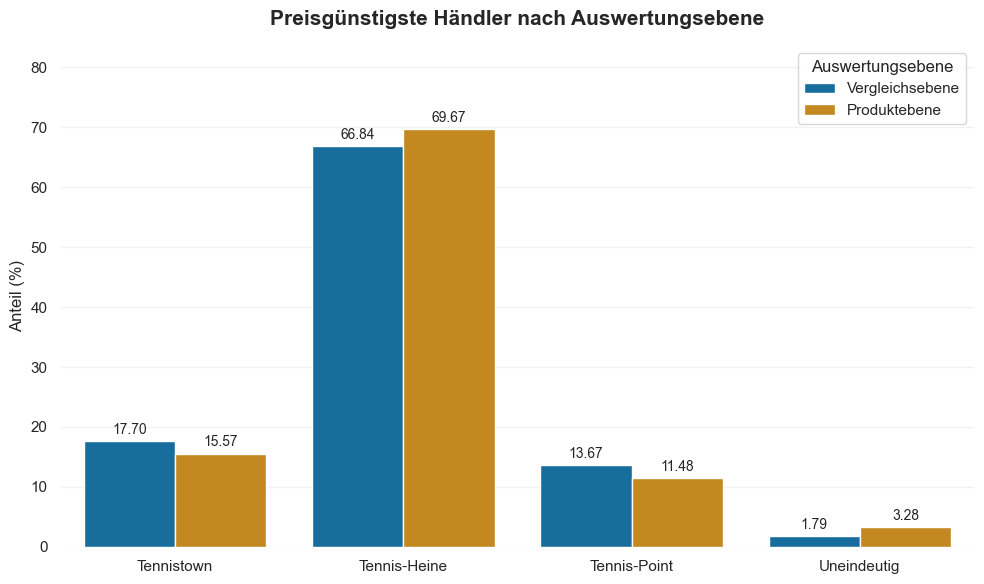

In [19]:
# --- PREISGÜNSTIGSTE HÄNDLER NACH AUSWERTUNGSEBENE VISUALISIEREN ---

# Ergebnisse der Vergleichsebene für die Visualisierung vorbereiten
df_comparison_level_plot = (
    df_lowest_price_comparison_overview[['Lowest price result', 'Share of price comparisons (%)']]
    .rename(columns={'Lowest price result': 'Result', 'Share of price comparisons (%)': 'Share (%)'})
)

df_comparison_level_plot['Analysis level'] = 'Vergleichsebene'

# Ergebnisse der Produktebene für die Visualisierung vorbereiten
df_product_level_plot = (
    df_lowest_price_product_overview[['Most frequently lowest-priced retailer', 'Share of product variants (%)']]
    .rename(columns={'Most frequently lowest-priced retailer': 'Result', 'Share of product variants (%)': 'Share (%)'})
)

df_product_level_plot['Analysis level'] = 'Produktebene'

# Uneindeutige Ergebnisse beider Auswertungsebenen einheitlich bezeichnen
df_comparison_level_plot['Result'] = df_comparison_level_plot['Result'].replace({'Tie': 'Uneindeutig'})
df_product_level_plot['Result'] = df_product_level_plot['Result'].replace({'No unique retailer': 'Uneindeutig'})

# Ergebnisse beider Auswertungsebenen zusammenführen
df_lowest_price_plot = pd.concat([df_comparison_level_plot, df_product_level_plot], ignore_index=True)

# Reihenfolge der Ergebnisse und Auswertungsebenen festlegen
lowest_price_result_order = retailer_order + ['Uneindeutig']
analysis_level_order = ['Vergleichsebene', 'Produktebene']

# Einheitliches Erscheinungsbild für die Visualisierungen festlegen
sns.set_theme(style='whitegrid', context='notebook')

# Diagrammfläche vorbereiten
fig, ax = plt.subplots(figsize=(10, 6))

# Gruppiertes Balkendiagramm erzeugen
sns.barplot(
    data=df_lowest_price_plot,
    x='Result',
    y='Share (%)',
    hue='Analysis level',
    order=lowest_price_result_order,
    hue_order=analysis_level_order,
    palette='colorblind',
    errorbar=None,
    ax=ax
)

# Prozentwerte über den Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# Diagramm beschriften
ax.set_title('Preisgünstigste Händler nach Auswertungsebene', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Anteil (%)')

# Legende und Gitternetz anpassen
ax.legend(title='Auswertungsebene')
ax.grid(axis='y', alpha=0.25)

# Zusätzlichen Platz für die Werte oberhalb der Balken schaffen
ax.set_ylim(0, df_lowest_price_plot['Share (%)'].max() * 1.2)

# Diagramm abschließend formatieren und anzeigen
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

Die Ergebnisse unterscheiden sich zwischen den beiden Auswertungsebenen nur geringfügig. Tennis-Heine weist sowohl innerhalb der einzelnen Preisvergleiche als auch auf Ebene der Produktvarianten mit deutlichem Abstand am häufigsten die niedrigste Preisposition auf.

Tennistown folgt auf beiden Ebenen vor Tennis-Point. Uneindeutige Ergebnisse treten nur bei einem kleinen Teil der Vergleiche und Produktvarianten auf. Das ähnliche Gesamtbild beider Ebenen zeigt, dass die Position von Tennis-Heine nicht ausschließlich durch besonders häufig beobachtete Produktvarianten entsteht.

## Preispositionen nach Produktkategorie vergleichen

Die bisherigen Ergebnisse werden ergänzend nach Produktkategorie aufgeschlüsselt. Dadurch wird untersucht, ob sich die beobachteten Preisabstände und die Verteilung der preisgünstigsten Händler zwischen Tennisschlägern, Tennisschuhen und Tennissaiten unterscheiden.

Für jede Kategorie werden die Anzahl vergleichbarer Produktvarianten, der Umfang vollständiger Preisvergleiche und der mediane Preisabstand ausgewiesen. Zusätzlich wird dargestellt, wie häufig die einzelnen Händler innerhalb der vollständigen Preisvergleiche allein den niedrigsten Preis aufweisen.

In [20]:
# --- PRODUKTKATEGORIE DER PREISVERGLEICHE ERGÄNZEN ---

# Für jede GTIN genau eine zugehörige Produktkategorie sichern; wiederholte Beobachtungen derselben GTIN und Kategorie werden entfernt
df_gtin_category = df_usable_common_product_data[['gtin_normalized', 'category']].drop_duplicates()

# Jedem vollständigen Preisvergleich anhand seiner GTIN die Produktkategorie zuordnen
# Einer Kategorie können viele Preisvergleiche angehören, jede GTIN darf jedoch nur genau einer Kategorie zugeordnet sein
df_price_comparison_by_category = df_price_comparison.merge(
    df_gtin_category,
    on='gtin_normalized',
    how='left',
    validate='many_to_one'
)

# Reihenfolge der Produktkategorien festlegen
category_order = ['rackets', 'shoes', 'strings']

# --- PREISABSTÄNDE NACH PRODUKTKATEGORIE ZUSAMMENFASSEN ---
df_category_price_overview = (
    df_price_comparison_by_category
    .groupby('category', sort=False)
    .agg(
        Product_variants=('gtin_normalized', 'nunique'),            # Anzahl unterschiedlicher vergleichbarer Produktvarianten bestimmen
        Complete_price_comparisons=('gtin_normalized', 'size'),     # Anzahl vollständiger Preisvergleiche bestimmen
        Median_price_spread_eur=('price_spread_eur', 'median'),     # Median der absoluten Preisabstände berechnen
        Median_price_spread_pct=('price_spread_pct', 'median')      # Median der prozentualen Preisabstände berechnen
    )
    .reset_index()
    .rename(columns={
        'category': 'Category',
        'Product_variants': 'Product variants',
        'Complete_price_comparisons': 'Complete price comparisons',
        'Median_price_spread_eur': 'Median price spread (€)',
        'Median_price_spread_pct': 'Median price spread (%)'
    })
)

# --- PREISGÜNSTIGSTE HÄNDLER NACH PRODUKTKATEGORIE ZUSAMMENFASSEN ---

# Prozentualen Anteil der jeweils preisgünstigsten Händler und Gleichstände innerhalb jeder Produktkategorie berechnen
df_lowest_price_category_shares = (
    pd.crosstab(df_price_comparison_by_category['category'], df_price_comparison_by_category['lowest_price_result'], normalize='index') * 100
)

# Händler und Gleichstände vollständig und einheitlich anordnen
df_lowest_price_category_shares = (
    df_lowest_price_category_shares
    .reindex(columns=retailer_order + ['Tie'], fill_value=0)
    .rename(columns={
        'Tennistown': 'Tennistown lowest (%)',
        'Tennis-Heine': 'Tennis-Heine lowest (%)',
        'Tennis-Point': 'Tennis-Point lowest (%)',
        'Tie': 'Tie (%)'
    })
    .reset_index()
    .rename(columns={'category': 'Category'})
)

# Preisabstände und Anteile der preisgünstigsten Händler über die gemeinsame Spalte Category verbinden
df_category_price_overview = df_category_price_overview.merge(
    df_lowest_price_category_shares,
    on='Category',
    how='left',
    validate='one_to_one'
)

# Sämtliche numerischen Kennzahlen auf zwei Nachkommastellen runden
df_category_price_overview = df_category_price_overview.round(2)

# Produktkategorien in der festgelegten Reihenfolge anordnen
df_category_price_overview = (
    df_category_price_overview
    .set_index('Category')
    .reindex(category_order)
    .reset_index()
)

print('--- PREISPOSITIONEN NACH PRODUKTKATEGORIE ---')
print('Zeigt Preisabstände und die Verteilung der preisgünstigsten Händler innerhalb der einzelnen Produktkategorien.\n')

display(df_category_price_overview)

--- PREISPOSITIONEN NACH PRODUKTKATEGORIE ---
Zeigt Preisabstände und die Verteilung der preisgünstigsten Händler innerhalb der einzelnen Produktkategorien.



,Category,Product variants,Complete price comparisons,Median price spread (€),Median price spread (%),Tennistown lowest (%),Tennis-Heine lowest (%),Tennis-Point lowest (%),Tie (%)
0,rackets,95,2854,30.05,18.43,21.20,60.58,15.94,2.28
1,shoes,1,14,19.95,24.95,0.00,0.00,100.00,0.00
2,strings,26,754,20.90,17.61,4.77,91.78,3.45,0.00


Bei den Tennisschlägern stehen 95 Produktvarianten mit insgesamt 2.854 vollständigen Preisvergleichen zur Verfügung. Der mediane Preisabstand beträgt 30,05 € beziehungsweise 18,43 %. Tennis-Heine weist in 60,58 % dieser Vergleiche allein den niedrigsten Preis auf. Tennistown erreicht einen Anteil von 21,20 % und Tennis-Point von 15,94 %.

Für Tennissaiten liegen 26 Produktvarianten und 754 vollständige Preisvergleiche vor. Der mediane Preisabstand fällt mit 20,90 € beziehungsweise 17,61 % etwas geringer aus. Tennis-Heine nimmt hier mit einem Anteil von 91,78 % besonders häufig die niedrigste Preisposition ein.

Die Ergebnisse für Tennisschuhe beruhen lediglich auf einer Produktvariante und 14 vollständigen Preisvergleichen. Tennis-Point weist zwar in allen diesen Vergleichen den niedrigsten Preis auf, aber aufgrund der sehr kleinen Produktbasis lässt sich daraus keine allgemeine Aussage über die Preisposition der Händler bei Tennisschuhen ableiten.

Insgesamt bestätigt die Auswertung für Tennisschläger und Tennissaiten die zuvor festgestellte Preisposition von Tennis-Heine. Die Häufigkeit, mit der Tennis-Heine den niedrigsten Preis aufweist, unterscheidet sich jedoch deutlich zwischen den Produktkategorien.

## Zeitlich aufeinanderfolgende Preisänderungen untersuchen

Abschließend wird explorativ untersucht, ob auf die Preisänderung eines Händlers im unmittelbar folgenden Abruffenster eine Preisänderung eines anderen Händlers folgt.

Eine solche Abfolge setzt drei unmittelbar aufeinanderfolgende vollständige Preisvergleiche derselben Produktvariante voraus:

- Zwischen dem ersten und zweiten Vergleich verändert genau ein Händler seinen Preis.
- Zwischen dem zweiten und dritten Vergleich bleibt der Preis dieses Händlers unverändert.
- Gleichzeitig verändert mindestens einer der beiden anderen Händler seinen Preis.

Die Beschränkung auf genau einen preisändernden Händler im ersten Übergang ermöglicht es, einen eindeutigen Ausgangspunkt der zeitlichen Abfolge festzulegen. Ändert dieser Händler seinen Preis im folgenden Übergang erneut, wird der Fall ausgeschlossen. Andernfalls wäre nicht eindeutig zu beurteilen, ob eine mögliche nachfolgende Anpassung eines anderen Händlers zeitlich auf die erste oder die zweite Preisänderung folgt.

Es wird keine übereinstimmende Änderungsrichtung vorausgesetzt. Sowohl gleichgerichtete Änderungen als auch gegenläufige Preisanpassungen werden zunächst als mögliche zeitliche Abfolgen erfasst.

Die Auswahlbedingungen sind bewusst eng gefasst, um mehrdeutige Abfolgen auszuschließen. Dadurch können mögliche Reaktionen unberücksichtigt bleiben. Die verbleibenden Fälle bieten jedoch eine besser abgrenzbare Grundlage für die explorative Betrachtung. Die Ergebnisse sind rein explorativ. Die zeitliche Abfolge belegt weder, dass ein Händler die Preisänderung eines Wettbewerbers beobachtet hat, noch dass die spätere Änderung eine kausale Reaktion darstellt.


In [21]:
# --- PREISVERGLEICHE FÜR DIE ZEITLICHE AUSWERTUNG VORBEREITEN ---

# Kopie der vollständigen Preisvergleiche einschließlich Produktkategorie erstellen
df_temporal_price_changes = df_price_comparison_by_category.copy()

# Die beiden täglichen Abrufe in ihre geplante zeitliche Reihenfolge übersetzen: run1 erhält den Wert 0 und run2 den Wert 1
df_temporal_price_changes['run_order'] = df_temporal_price_changes['run'].map({'run1': 0, 'run2': 1})

# Erstes in den Preisvergleichen enthaltenes Abrufdatum als Ausgangsdatum verwenden
first_comparison_date = df_temporal_price_changes['run_date'].min()

# Jedem geplanten Abruffenster eine fortlaufende Nummer zuweisen; jeder neue Tag erhöht die Nummer um 2; run2 liegt jeweils eine Position nach run1
df_temporal_price_changes['comparison_window_order'] = (
    (df_temporal_price_changes['run_date'] - first_comparison_date).dt.days * 2
    + df_temporal_price_changes['run_order']
)

# Preisvergleiche zunächst nach Produktvariante und innerhalb jeder Produktvariante nach dem geplanten Abruffenster sortieren
df_temporal_price_changes = (
    df_temporal_price_changes
    .sort_values(['gtin_normalized', 'comparison_window_order'])
    .reset_index(drop=True)
)

# Preisvergleiche nach GTIN gruppieren, damit Verschiebungen mit shift() ausschließlich innerhalb derselben Produktvariante erfolgen;
# --> Damit keine Preise oder Preisänderungen zwischen unterschiedlichen Produkten übertragen werden
temporal_price_groups = df_temporal_price_changes.groupby('gtin_normalized', sort=False)

# Innerhalb jeder Produktvariante die Nummer des vorherigen vorhandenen Vergleichsfensters in einer zusätzlichen Spalte ergänzen
df_temporal_price_changes['previous_comparison_window_order'] = temporal_price_groups['comparison_window_order'].shift(1)

# Prüfen, ob der vorherige Vergleich aus dem unmittelbar vorhergehenden Abruffenster stammt
# Unterscheiden sich die Nummern genau um 1, handelt es sich um unmittelbar aufeinanderfolgende geplante Abruffenster
# Fehlt ein Abruffenster, ist der Abstand größer als 1 und es wird kein zeitlich unmittelbarer Vergleich angenommen
df_temporal_price_changes['direct_previous_comparison'] = (
    df_temporal_price_changes['comparison_window_order']
    .sub(df_temporal_price_changes['previous_comparison_window_order'])
    .eq(1)
)

# Preisänderungen der einzelnen Händler gegenüber dem vorherigen Vergleich berechnen
price_change_columns = []

for retailer in retailer_order:
    previous_price_column = f'{retailer}_previous_price'
    price_change_column = f'{retailer}_price_change_eur'

    # Vorherigen Preis desselben Händlers und derselben Produktvariante ergänzen
    df_temporal_price_changes[previous_price_column] = temporal_price_groups[retailer].shift(1)

    # Preisänderung gegenüber dem vorherigen Vergleich berechnen (aktueller Preis - vorheriger Preis)
    df_temporal_price_changes[price_change_column] = (
        df_temporal_price_changes[retailer]
        - df_temporal_price_changes[previous_price_column]
    ).round(2)

    # Preisänderung nur bei unmittelbar aufeinanderfolgenden Abruffenstern behalten
    df_temporal_price_changes[price_change_column] = (
        df_temporal_price_changes[price_change_column]
        .where(df_temporal_price_changes['direct_previous_comparison'])
    )

    # Namen der erzeugten Preisänderungsspalte für die spätere gemeinsame Auswertung sichern
    price_change_columns.append(price_change_column)

# Für jeden Händler kennzeichnen, ob eine vorhandene Preisänderung ungleich 0 vorliegt
df_price_change_exists = df_temporal_price_changes[price_change_columns].notna() & df_temporal_price_changes[price_change_columns].ne(0)

# Anzahl der Händler mit einer Preisänderung innerhalb jedes Übergangs bestimmen (True-Werte je Zeile zählen)
df_temporal_price_changes['changing_retailer_count'] = df_price_change_exists.sum(axis=1)

# Übergänge kennzeichnen, bei denen genau ein Händler seinen Preis verändert
# True, wenn genau ein Händler seinen Preis verändert; False, wenn kein Händler oder mehrere Händler ihren Preis verändern
df_temporal_price_changes['single_retailer_change'] = df_temporal_price_changes['changing_retailer_count'].eq(1)

In [22]:
# --- UNMITTELBAR FOLGENDE PREISÄNDERUNGEN ERGÄNZEN ---

# Nummer und Abrufinformationen des folgenden Vergleichsfensters ergänzen
df_temporal_price_changes['following_comparison_window_order'] = temporal_price_groups['comparison_window_order'].shift(-1)
df_temporal_price_changes['following_run_date'] = temporal_price_groups['run_date'].shift(-1)
df_temporal_price_changes['following_run'] = temporal_price_groups['run'].shift(-1)

# Prüfen, ob auch das folgende Vergleichsfenster unmittelbar anschließt
df_temporal_price_changes['direct_following_comparison'] = (
    df_temporal_price_changes['following_comparison_window_order']
    .sub(df_temporal_price_changes['comparison_window_order'])
    .eq(1)
)

# Preisänderungen aus dem folgenden Übergang für jeden Händler ergänzen
for retailer in retailer_order:
    price_change_column = f'{retailer}_price_change_eur'
    following_change_column = f'{retailer}_following_price_change_eur'
    df_temporal_price_changes[following_change_column] = temporal_price_groups[price_change_column].shift(-1)


# --- MÖGLICHE ZEITLICHE PREISÄNDERUNGSFOLGEN AUSWÄHLEN ---

# Übergänge auswählen, bei denen zunächst genau ein Händler seinen Preis ändert und ein unmittelbar folgendes Vergleichsfenster vorhanden ist
df_eligible_initial_changes = df_temporal_price_changes.loc[
    df_temporal_price_changes['single_retailer_change']
    & df_temporal_price_changes['direct_following_comparison']
]

temporal_candidate_list = []

# Geeignete zeitliche Abfolgen einzeln prüfen und für die Ausgabe sammeln
for _, row in df_eligible_initial_changes.iterrows():

    # Händler bestimmen, der seinen Preis im ersten Übergang verändert
    initial_changing_retailer = None

    for retailer in retailer_order:
        price_change = row[f'{retailer}_price_change_eur']

        if pd.notna(price_change) and price_change != 0:
            initial_changing_retailer = retailer
            break

    # Abfolge nur berücksichtigen, wenn dieser Händler seinen Preis im folgenden Übergang nicht erneut verändert
    initial_following_change = row[f'{initial_changing_retailer}_following_price_change_eur']

    if pd.isna(initial_following_change) or initial_following_change != 0:
        continue

    # Andere Händler mit einer Preisänderung im folgenden Übergang sammeln
    following_retailers = []
    following_price_changes = []

    for retailer in retailer_order:
        if retailer == initial_changing_retailer:
            continue

        following_change = row[f'{retailer}_following_price_change_eur']

        if pd.notna(following_change) and following_change != 0:
            following_retailers.append(retailer)
            following_price_changes.append(f'{retailer}: {following_change:+.2f} €')

    # Abfolge verwerfen, wenn kein anderer Händler seinen Preis verändert
    if not following_retailers:
        continue

    # Gefundene Abfolge für die Ergebnistabelle sichern
    temporal_candidate_list.append({
        'GTIN': row['gtin_normalized'],
        'Category': row['category'],
        'Initial change date': row['run_date'],
        'Initial run': row['run'],
        'Initial changing retailer': initial_changing_retailer,
        'Initial price change (€)': row[
            f'{initial_changing_retailer}_price_change_eur'
        ],
        'Following change date': row['following_run_date'],
        'Following run': row['following_run'],
        'Following changing retailers': ', '.join(following_retailers),
        'Following price changes': '; '.join(following_price_changes)
    })

# Gefundene Abfolgen als Tabelle speichern
df_temporal_price_change_candidates = pd.DataFrame(temporal_candidate_list)

# Ergebnistabelle chronologisch anordnen, sofern Fälle gefunden wurden
if not df_temporal_price_change_candidates.empty:
    df_temporal_price_change_candidates = (
        df_temporal_price_change_candidates
        .sort_values(['Initial change date', 'Initial run', 'GTIN'])
        .reset_index(drop=True)
    )


# --- ERGEBNISSE DER EXPLORATIVEN SUCHE ZUSAMMENFASSEN ---
df_temporal_price_change_overview = pd.DataFrame([{
    'Direct comparison transitions': int(df_temporal_price_changes['direct_previous_comparison'].sum()),
    'Transitions with price change': int((df_temporal_price_changes['changing_retailer_count'].gt(0)).sum()),
    'Single-retailer changes with direct following comparison': len(df_eligible_initial_changes),
    'Candidate sequences': len(df_temporal_price_change_candidates),
    'Product variants with candidate sequence': (
        df_temporal_price_change_candidates['GTIN'].nunique()
        if not df_temporal_price_change_candidates.empty
        else 0
    )
}])

print('--- ZEITLICH AUFEINANDERFOLGENDE PREISÄNDERUNGEN ---')
print('Zeigt den Umfang der geprüften Vergleichsübergänge und der gefundenen zeitlichen Abfolgen.\n')

display(df_temporal_price_change_overview)

print('--- MÖGLICHE ZEITLICHE PREISÄNDERUNGSFOLGEN ---')
print('Zeigt Fälle, in denen auf die Preisänderung eines Händlers im folgenden Abruffenster die Änderung eines anderen Händlers folgt.\n')

display(df_temporal_price_change_candidates)

--- ZEITLICH AUFEINANDERFOLGENDE PREISÄNDERUNGEN ---
Zeigt den Umfang der geprüften Vergleichsübergänge und der gefundenen zeitlichen Abfolgen.



,Direct comparison transitions,Transitions with price change,Single-retailer changes with direct following comparison,Candidate sequences,Product variants with candidate sequence
0,2242,459,215,12,11


--- MÖGLICHE ZEITLICHE PREISÄNDERUNGSFOLGEN ---
Zeigt Fälle, in denen auf die Preisänderung eines Händlers im folgenden Abruffenster die Änderung eines anderen Händlers folgt.



,GTIN,Category,Initial change date,Initial run,Initial changing retailer,Initial price change (€),Following change date,Following run,Following changing retailers,Following price changes
0,00198772135324,rackets,2026-06-28,run2,Tennis-Point,2.00,2026-06-29,run1,Tennistown,Tennistown: +18.75 €
1,00198772139971,rackets,2026-06-29,run1,Tennistown,20.74,2026-06-29,run2,Tennis-Point,Tennis-Point: +26.00 €
2,00198772139988,rackets,2026-06-29,run1,Tennistown,20.74,2026-06-29,run2,Tennis-Point,Tennis-Point: +26.00 €
3,00726423218012,rackets,2026-06-30,run2,Tennis-Point,30.00,2026-07-01,run1,Tennis-Heine,Tennis-Heine: -30.00 €
4,00726423218029,rackets,2026-06-30,run2,Tennis-Point,30.00,2026-07-01,run1,Tennis-Heine,Tennis-Heine: -30.00 €
5,00045566179722,rackets,2026-07-01,run1,Tennis-Point,5.00,2026-07-01,run2,Tennistown,Tennistown: -13.99 €
6,00726423218128,rackets,2026-07-01,run1,Tennis-Point,-30.00,2026-07-01,run2,"Tennistown, Tennis-Heine",Tennistown: -19.79 €; Tennis-Heine: -25.00 €
7,00045566182616,rackets,2026-07-05,run2,Tennis-Point,-5.00,2026-07-06,run1,Tennistown,Tennistown: +19.99 €
8,00045566182623,rackets,2026-07-05,run2,Tennis-Point,-5.00,2026-07-06,run1,Tennistown,Tennistown: +19.99 €
9,00045566179722,rackets,2026-07-06,run1,Tennistown,13.99,2026-07-06,run2,Tennis-Point,Tennis-Point: -5.00 €


Von den 2.242 unmittelbar aufeinanderfolgenden Vergleichsübergängen wird bei 459 Übergängen mindestens eine Preisänderung festgestellt. In 215 Fällen verändert zunächst genau ein Händler seinen Preis und für dieselbe Produktvariante liegt zusätzlich ein vollständiger Preisvergleich im unmittelbar folgenden Abruffenster vor. Von diesen 215 Ausgangsfällen erfüllen zwölf auch die beiden weiteren Bedingungen: Der zuerst preisändernde Händler verändert seinen Preis im folgenden Übergang nicht erneut und gleichzeitig verändert mindestens ein anderer Händler seinen Preis. Die zwölf zeitlichen Abfolgen verteilen sich auf elf Produktvarianten. Sämtliche gefundenen Fälle betreffen Tennisschläger.

In sieben der zwölf Abfolgen verändert Tennis-Point zuerst den Preis, in den übrigen fünf Fällen Tennistown. Tennis-Heine tritt innerhalb der ausgewählten Abfolgen nicht als zuerst preisändernder Händler auf, verändert seinen Preis jedoch in drei nachfolgenden Übergängen. Aufgrund der geringen Fallzahl und der insgesamt niedrigen Preisdynamik von Tennis-Heine lässt sich daraus aber keine allgemeine Rollenverteilung zwischen den Händlern ableiten.

Die Kandidatentabelle enthält sowohl gleichgerichtete als auch gegenläufige Preisänderungen. Die Fälle zeigen damit lediglich, dass auf die Änderung eines Händlers im folgenden Abruffenster eine Änderung mindestens eines anderen Händlers beobachtet wird. Ob tatsächlich eine Wettbewerbsreaktion vorliegt, kann aus der zeitlichen Reihenfolge allein nicht abgeleitet werden.

Die geringe Anzahl gefundener Abfolgen zeigt, dass dieses Muster unter den bewusst eng gefassten Auswahlbedingungen nur vereinzelt auftritt. Die Kandidaten werden daher nicht als Nachweis eines systematischen Reaktionsverhaltens interpretiert, sondern als Grundlage für die nachfolgende Betrachtung ausgewählter Preisverläufe verwendet.

### Ausgewählte zeitliche Preisverläufe betrachten

Zur näheren Betrachtung werden zwei der identifizierten Abfolgen ausgewählt. Berücksichtigt werden ein gleichgerichteter und ein gegenläufiger Fall. Vor der Visualisierung werden die zugehörigen Produktinformationen der drei Händler ausgegeben. Dadurch kann kontrolliert werden, welche konkrete Produktvariante hinter der jeweiligen GTIN steht.

In [23]:
# --- PRODUKTINFORMATIONEN DER AUSGEWÄHLTEN FÄLLE AUSGEBEN ---

# GTINs des gleichgerichteten und des gegenläufigen Falls festlegen
selected_temporal_gtins = [
    '00726423218128',
    '00726423218012'
]

# Händlerzuordnungen und Produktinformationen der ausgewählten GTINs sichern
df_selected_temporal_product_details = (
    df_usable_common_product_data
    .loc[
        df_usable_common_product_data['gtin_normalized'].isin(selected_temporal_gtins),
        ['gtin_normalized', 'retailer', 'category', 'brand', 'name', 'reference_variant']
    ]
    # Wiederholte Beobachtungen derselben Produktzuordnung entfernen
    .drop_duplicates()
    .copy()
)

# Händler für die Kontrollausgabe in der festgelegten Reihenfolge anordnen
df_selected_temporal_product_details['retailer'] = pd.Categorical(
    df_selected_temporal_product_details['retailer'],
    categories=retailer_order,
    ordered=True
)

df_selected_temporal_product_details = (
    df_selected_temporal_product_details
    .sort_values(['gtin_normalized', 'retailer'])
    .reset_index(drop=True)
)

print('--- PRODUKTINFORMATIONEN DER AUSGEWÄHLTEN PREISVERLÄUFE ---')
print('Zeigt die händlerspezifischen Produktbezeichnungen und Referenzvarianten der beiden ausgewählten GTINs.\n')

display(df_selected_temporal_product_details)

--- PRODUKTINFORMATIONEN DER AUSGEWÄHLTEN PREISVERLÄUFE ---
Zeigt die händlerspezifischen Produktbezeichnungen und Referenzvarianten der beiden ausgewählten GTINs.



,gtin_normalized,retailer,category,brand,name,reference_variant
0,00726423218012,Tennistown,rackets,Head,Head Tennisschläger Extreme Pro 98in/305g/Turn...,L2
1,00726423218012,Tennis-Heine,rackets,Head,Head Extreme Pro 2024 Tennisschläger,L2
2,00726423218012,Tennis-Point,rackets,Head,Extreme Pro 2024 Turnierschläger,L2
3,00726423218128,Tennistown,rackets,Head,Head Tennisschläger Extreme MP 100in/300g/Turn...,L3
4,00726423218128,Tennis-Heine,rackets,Head,Head Extreme MP 2024 Tennisschläger,L3
5,00726423218128,Tennis-Point,rackets,Head,Extreme MP 2024 Turnierschläger,L3


Die GTIN `00726423218128` bezeichnet bei allen drei Händlern den Head Extreme MP 2024 in der Griffstärke L3. Bei diesem Fall werden gleichgerichtete Preisänderungen beobachtet: Nachdem Tennis-Point seinen Preis senkt, werden im folgenden Abruffenster auch bei Tennistown und Tennis-Heine Preissenkungen festgestellt.

Die GTIN `00726423218012` bezeichnet den Head Extreme Pro 2024 in der Griffstärke L2. Dieser Fall wird als gegenläufiges Beispiel ausgewählt: Tennis-Point erhöht zunächst seinen Preis, während Tennis-Heine seinen Preis im unmittelbar folgenden Abruffenster senkt.

Für beide Produktvarianten werden sämtliche vorhandenen vollständigen Drei-Händler-Preisvergleiche des Erhebungszeitraums dargestellt. Fehlende Vergleichsfenster werden nicht ergänzt und die Preislinien werden nicht über solche Lücken hinweg verbunden. Die jeweils untersuchte Abfolge aus drei unmittelbar aufeinanderfolgenden Vergleichsfenstern wird in der zugehörigen Abbildung grau hervorgehoben.

In [24]:
# --- AUSGEWÄHLTE ZEITLICHE PREISVERLÄUFE VORBEREITEN ---

# Aussage und Diagrammtitel für die beiden ausgewählten GTINs festlegen
selected_temporal_cases = {
    '00726423218128': 'Gleichgerichtete Änderungen\nHead Extreme MP 2024 (L3)',
    '00726423218012': 'Gegenläufige Änderungen\nHead Extreme Pro 2024 (L2)'
}

# Zugehörige Fälle aus der Kandidatentabelle auswählen
df_selected_temporal_candidates = (
    df_temporal_price_change_candidates
    .loc[df_temporal_price_change_candidates['GTIN'].isin(selected_temporal_gtins)]
    .copy()
)

# Vergleichsfensternummern anhand von GTIN, Datum und Run für die spätere Hervorhebung der ausgewählten Abfolgen bereitstellen
df_candidate_window_lookup = df_temporal_price_changes[['gtin_normalized', 'run_date', 'run', 'comparison_window_order']]

# Nummer des Vergleichsfensters ergänzen, in dem die erste Änderung auftritt
df_selected_temporal_candidates = (
    df_selected_temporal_candidates
    .merge(
        df_candidate_window_lookup,
        left_on=['GTIN', 'Initial change date', 'Initial run'],
        right_on=['gtin_normalized', 'run_date', 'run'],
        how='left',
        validate='one_to_one'
    )
    .rename(columns={'comparison_window_order': 'Initial comparison window order'})
    .drop(columns=['gtin_normalized', 'run_date', 'run'])
)

# Sämtliche vollständigen Preisvergleiche der beiden ausgewählten GTINs übernehmen
df_selected_temporal_history = (
    df_temporal_price_changes
    .loc[
        df_temporal_price_changes['gtin_normalized'].isin(selected_temporal_gtins),
        ['gtin_normalized', 'run_date', 'run', 'comparison_window_order'] + retailer_order
    ]
    .copy()
    .sort_values(['gtin_normalized', 'comparison_window_order'])
    .reset_index(drop=True)
)

# Beginn eines neuen Linienabschnitts kennzeichnen, wenn das vorherige geplante Vergleichsfenster fehlt
df_selected_temporal_history['new_price_segment'] = df_selected_temporal_history.groupby('gtin_normalized')['comparison_window_order'].diff().ne(1)

# Zusammenhängende Beobachtungen jeder GTIN fortlaufend nummerieren
df_selected_temporal_history['price_segment'] = df_selected_temporal_history.groupby('gtin_normalized')['new_price_segment'].cumsum()

# Händlerspalten für die Visualisierung untereinander anordnen
df_selected_temporal_plot = df_selected_temporal_history.melt(
    id_vars=[
        'gtin_normalized',
        'run_date',
        'run',
        'comparison_window_order',
        'price_segment'
    ],
    value_vars=retailer_order,
    var_name='Retailer',
    value_name='Price (€)'
)

# Eindeutige Kennzeichnung jedes zusammenhängenden Linienabschnitts erzeugen
df_selected_temporal_plot['line_segment'] = (
    df_selected_temporal_plot['gtin_normalized'].astype(str) + '_'
    + df_selected_temporal_plot['Retailer'].astype(str) + '_'
    + df_selected_temporal_plot['price_segment'].astype(str)
)

# Fensternummer der ersten Preisänderung für jede ausgewählte GTIN speichern
initial_window_order_by_gtin = df_selected_temporal_candidates.set_index('GTIN')['Initial comparison window order'].to_dict()

# Einheitliche Positionen für die Datumsbeschriftungen der x-Achse festlegen
maximum_comparison_window_order = int(df_temporal_price_changes['comparison_window_order'].max())
comparison_tick_positions = list(range(0, maximum_comparison_window_order + 1, 14))

# Letztes vorhandenes Vergleichsfenster gegebenenfalls zusätzlich anzeigen
if comparison_tick_positions[-1] != maximum_comparison_window_order:
    comparison_tick_positions.append(maximum_comparison_window_order)

# Fensternummern für die Achse wieder in Datumsangaben übersetzen
comparison_tick_labels = [
    (first_comparison_date + pd.Timedelta(days=position // 2)).strftime('%d.%m.%Y')
    for position in comparison_tick_positions
]

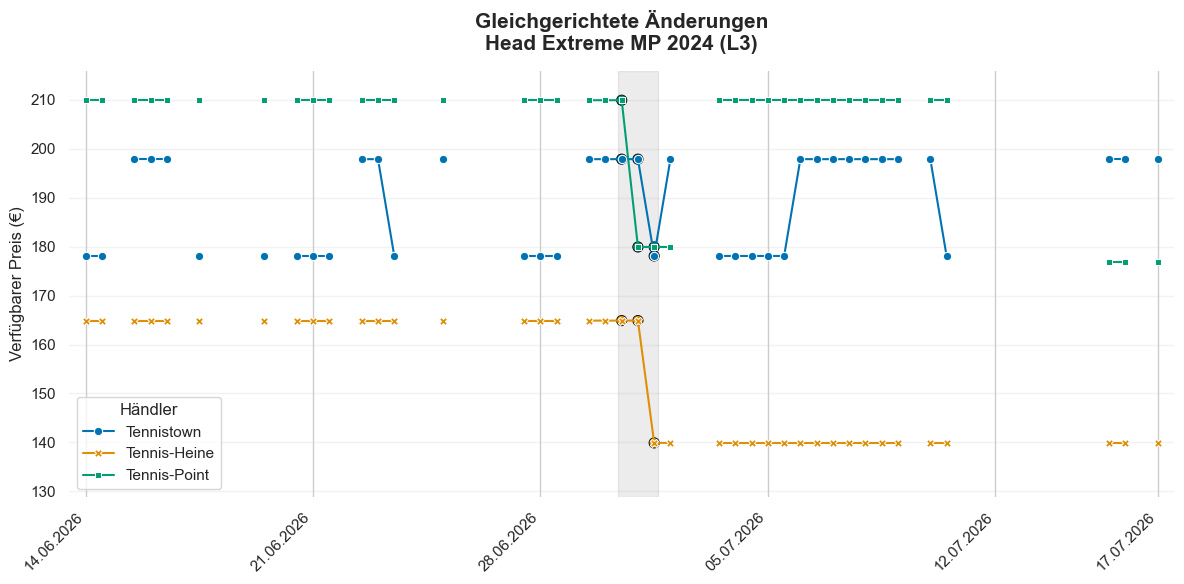

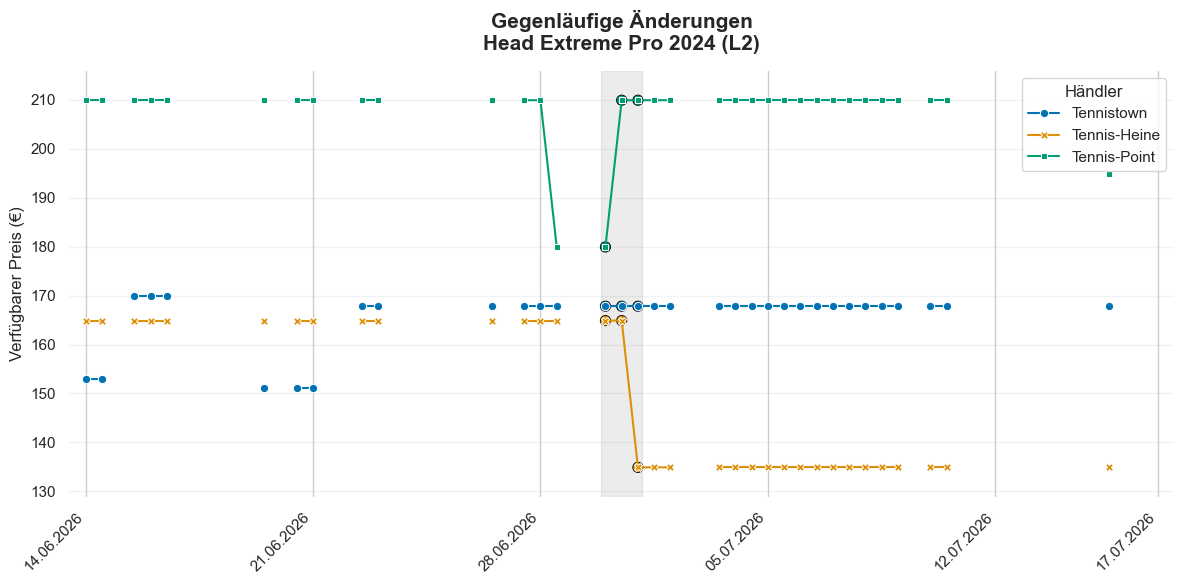

In [25]:
# --- BEOBACHTBARE PREISVERLÄUFE DER AUSGEWÄHLTEN FÄLLE VISUALISIEREN ---

# Einheitliche Preisskala für beide Abbildungen festlegen
minimum_selected_price = df_selected_temporal_plot['Price (€)'].min()
maximum_selected_price = df_selected_temporal_plot['Price (€)'].max()
price_axis_margin = (maximum_selected_price - minimum_selected_price) * 0.08

# Für jede ausgewählte Produktvariante eine separate Abbildung erzeugen
for gtin, case_title in selected_temporal_cases.items():

    # Sämtliche vorhandenen Preisvergleiche der aktuellen GTIN auswählen
    df_case_plot = df_selected_temporal_plot.loc[df_selected_temporal_plot['gtin_normalized'].eq(gtin)]

    # Fensternummer bestimmen, in der die erste Preisänderung beobachtet wird
    initial_window_order = initial_window_order_by_gtin[gtin]

    # Die drei Vergleichsfenster der untersuchten Abfolge kennzeichnen
    selected_window_mask = df_case_plot['comparison_window_order'].between(initial_window_order - 1, initial_window_order + 1)

    # Separate Diagrammfläche in derselben Größe wie in Notebook 03 vorbereiten
    fig, ax = plt.subplots(figsize=(12, 6))

    # Preisverläufe darstellen; getrennte Segmente verhindern das Verbinden der Linien über fehlende Vergleichsfenster
    sns.lineplot(
        data=df_case_plot,
        x='comparison_window_order',
        y='Price (€)',
        hue='Retailer',
        style='Retailer',
        units='line_segment',
        estimator=None,
        hue_order=retailer_order,
        style_order=retailer_order,
        palette='colorblind',
        markers=True,
        dashes=False,
        linewidth=1.5,
        ax=ax
    )

    # Bereich der ausgewählten Drei-Fenster-Abfolge grau hervorheben
    ax.axvspan(initial_window_order - 1.25, initial_window_order + 1.25, color='grey', alpha=0.15)

    # Datenpunkte innerhalb der ausgewählten Abfolge zusätzlich hervorheben
    sns.scatterplot(
        data=df_case_plot.loc[selected_window_mask],
        x='comparison_window_order',
        y='Price (€)',
        hue='Retailer',
        hue_order=retailer_order,
        palette='colorblind',
        s=55,
        edgecolor='black',
        linewidth=0.6,
        legend=False,
        ax=ax
    )

    # Diagramm beschriften
    ax.set_title(case_title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Verfügbarer Preis (€)')

    # Einheitliche Datums- und Preisskala verwenden
    ax.set_xticks(comparison_tick_positions)
    ax.set_xticklabels(comparison_tick_labels, rotation=45, ha='right')
    ax.set_xlim(-1, maximum_comparison_window_order + 1)
    ax.set_ylim(minimum_selected_price - price_axis_margin, maximum_selected_price + price_axis_margin)

    # Legende und Gitternetz anpassen
    ax.legend(title='Händler')
    ax.grid(axis='y', alpha=0.25)

    # Diagramm abschließend formatieren und anzeigen
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()
    plt.show()

Im gleichgerichteten Beispiel des Head Extreme MP 2024 in der Griffstärke L3 wird im markierten Zeitraum zunächst bei Tennis-Point eine Preissenkung beobachtet. Im unmittelbar folgenden Abruffenster sinken auch die Preise bei Tennistown und Tennis-Heine. Der Fall erfüllt damit die festgelegten Bedingungen einer gleichgerichteten zeitlichen Abfolge.

Beim Head Extreme Pro 2024 in der Griffstärke L2 zeigt sich dagegen eine gegenläufige Entwicklung. Tennis-Point erhöht zunächst seinen Preis, während Tennis-Heine ihn im unmittelbar folgenden Abruffenster senkt. Die unterschiedliche Änderungsrichtung verdeutlicht, dass eine zeitliche Abfolge nicht automatisch als preisliche Anpassung an den zuerst preisändernden Händler interpretiert werden kann.

Die dargestellten Preisverläufe ordnen die jeweils markierte Abfolge in den gesamten Erhebungszeitraum ein. Unterbrechungen der Linien kennzeichnen fehlende vollständige Drei-Händler-Vergleiche. Die fehlenden Preisstände werden nicht ergänzt und die Linien nicht über diese Lücken hinweg fortgeführt.

Bei den beiden dargestellten Verläufen handelt es sich um bewusst ausgewählte Beispiele aus lediglich zwölf gefundenen zeitlichen Abfolgen. Der gleichgerichtete Fall ist grundsätzlich mit einer möglichen nachfolgenden Wettbewerbsreaktion vereinbar. Aus der zeitlichen Reihenfolge allein lässt sich jedoch nicht ableiten, ob Tennistown und Tennis-Heine tatsächlich auf die vorherige Preisänderung von Tennis-Point reagiert haben. Die Beispiele dienen daher ausschließlich der explorativen Veranschaulichung möglicher gleichgerichteter und gegenläufiger Entwicklungen und liefern keinen Nachweis kausaler Wettbewerbsreaktionen.